In [1]:
thread_cap = 16

# make sure to cap thread usage to avoid overloading the system and causing performance degradation
import os
os.environ["OMP_NUM_THREADS"] = str(thread_cap)       # OpenMP (used by many libs)
os.environ["OPENBLAS_NUM_THREADS"] = str(thread_cap)  # OpenBLAS
os.environ["MKL_NUM_THREADS"] = str(thread_cap)      # Intel MKL
os.environ["VECLIB_MAXIMUM_THREADS"] = str(thread_cap) # macOS Accelerate
os.environ["NUMEXPR_NUM_THREADS"] = str(thread_cap)   # numexpr

In [2]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
species = "mmusculus"
index_dir = project_dir / "Index" / "mouse"
analysis_name = "Analysis_2"
analysis_dir = Path.cwd() 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [6]:
data_10x = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='10x', assay ="10x", data_title='10X Genomics', type="standard")
data_polyT = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='polyT', assay="parse", data_title='Parse 3\'')
data_randO = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Quality Control Comparison

In [7]:
# Path to save gene metadata so don't need to query Ensembl more than once
gene_info = plotting.query_ensembl(analysis_dir, index_dir=index_dir, overwrite=True)

In [8]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


14,462 cells passed the 300 UMI threshold for 10X Genomics
Applied CPM normalization and log1p transformation to the filtered data.
31,951 cells passed the 400 UMI threshold for Parse 3'
Applied CPM normalization and log1p transformation to the filtered data.
29,510 cells passed the 400 UMI threshold for Parse Random Oligo
Applied CPM normalization and log1p transformation to the filtered data.
33,174 cells passed the 400 UMI threshold for Parse
Applied CPM normalization and log1p transformation to the filtered data.


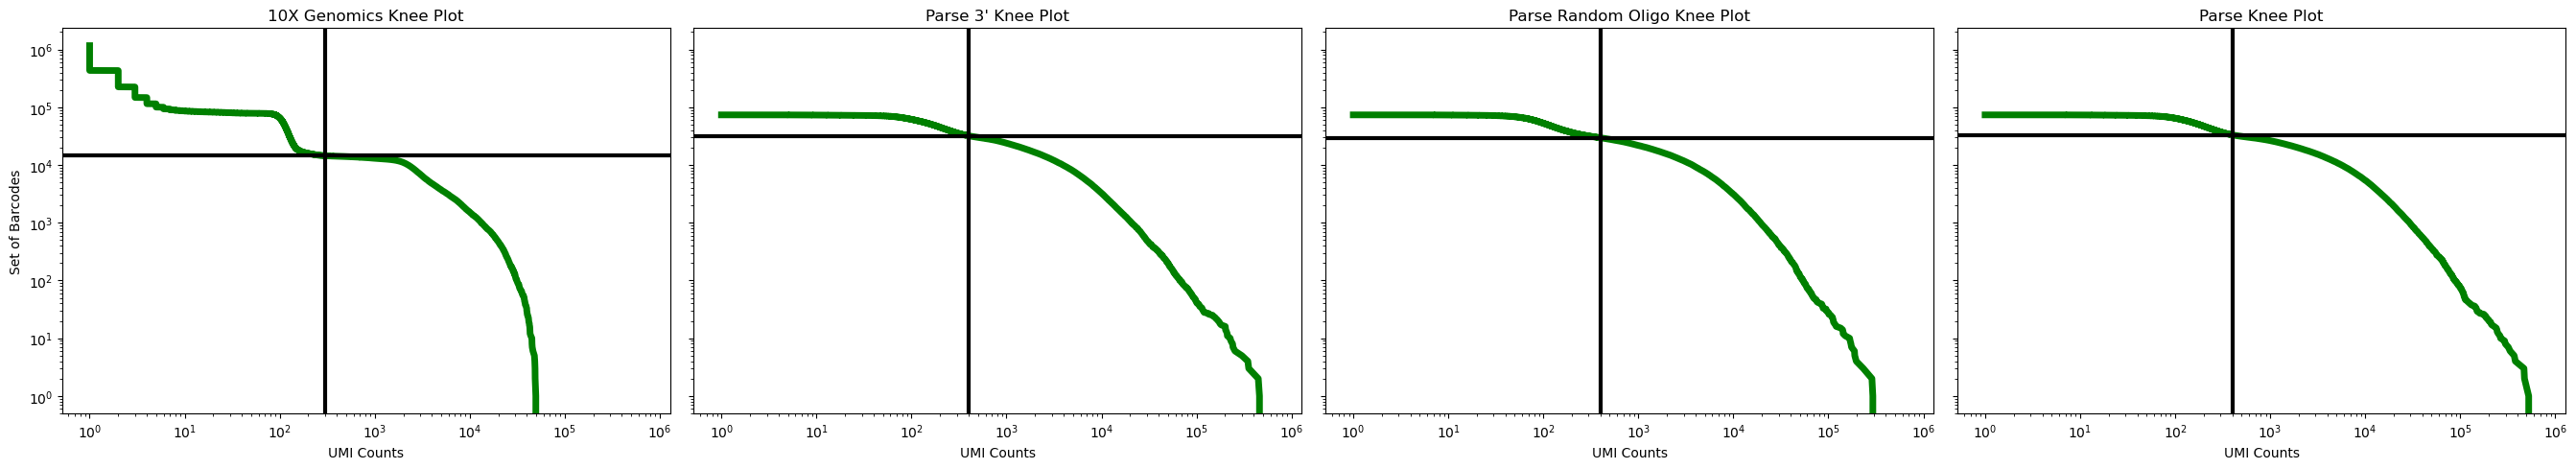

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

cutoffs = [300, 400, 400, 400]

datasets = []
for i, (data, cutoff) in enumerate(zip(raw_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff, transform=True))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()

In [10]:
full_gene_info_path = project_dir / analysis_dir 
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)

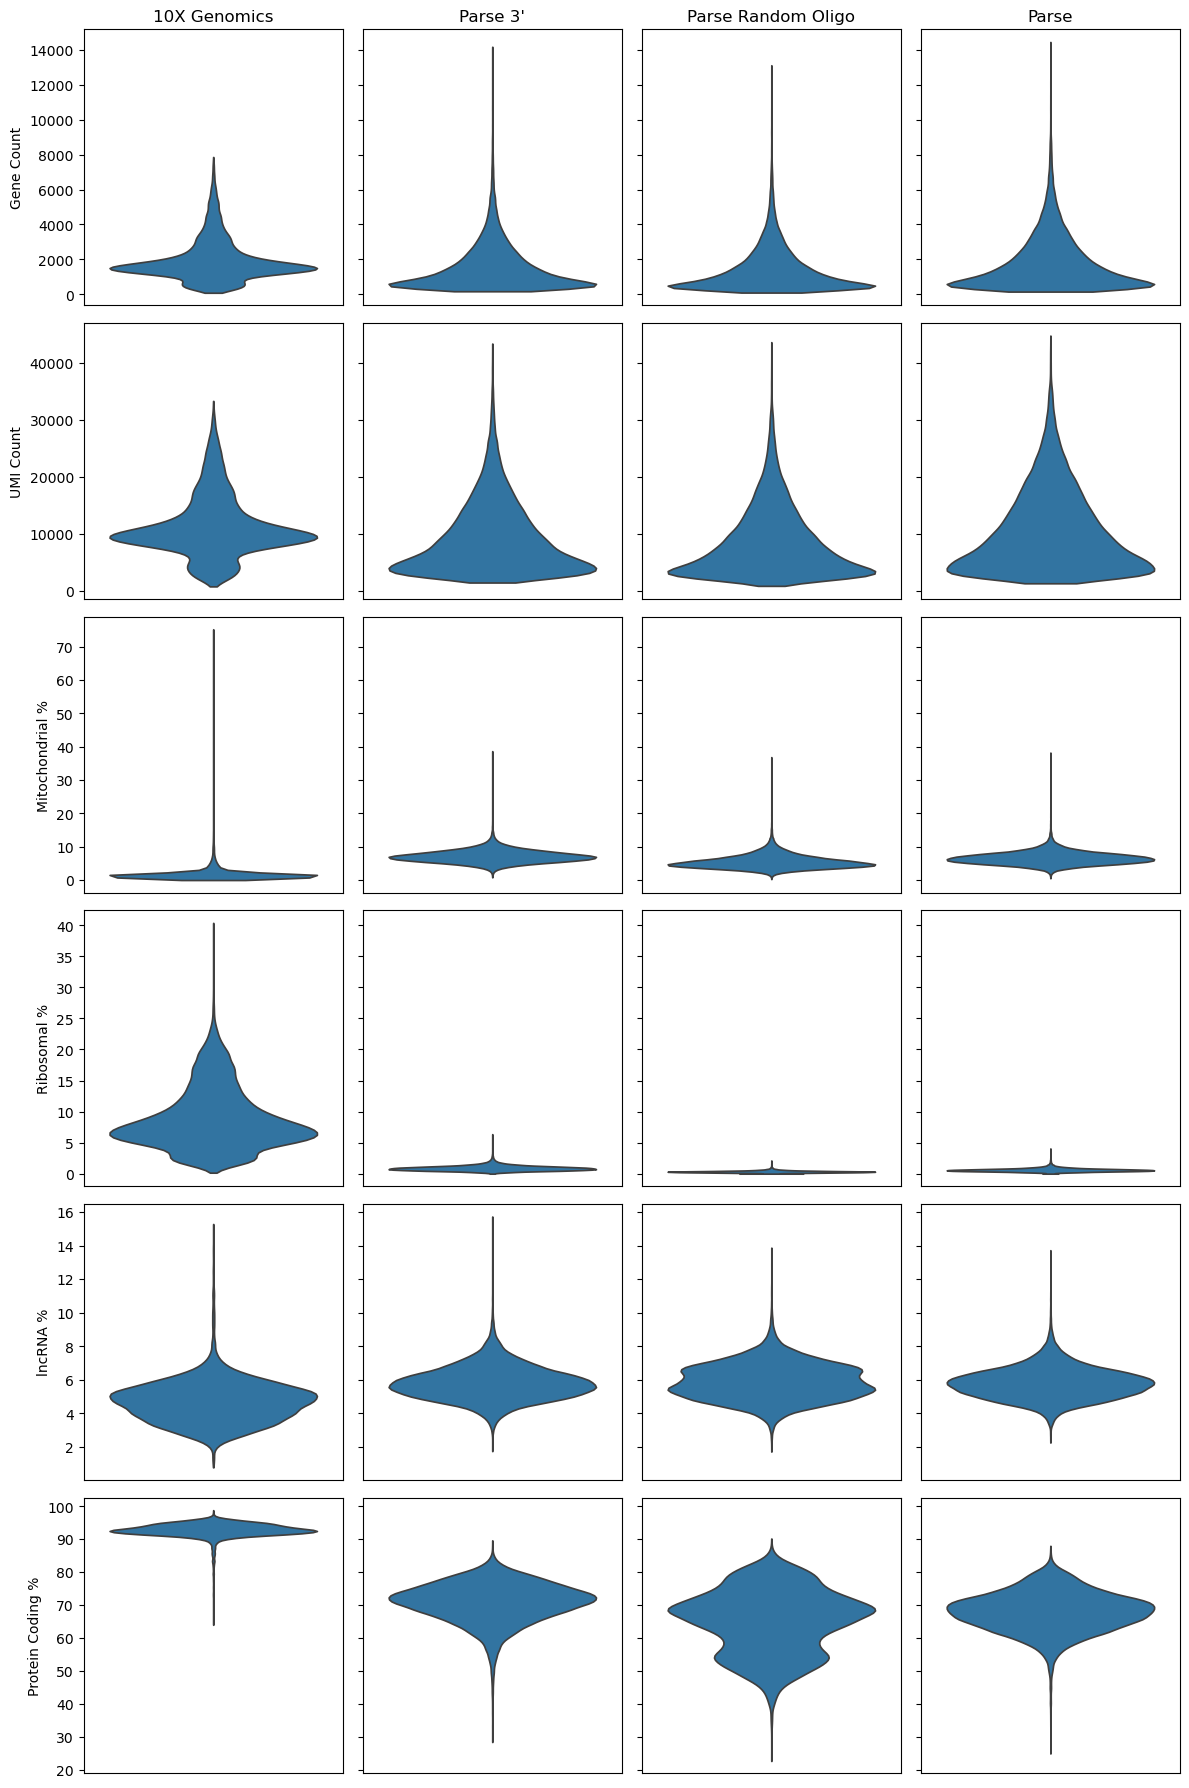

In [11]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))

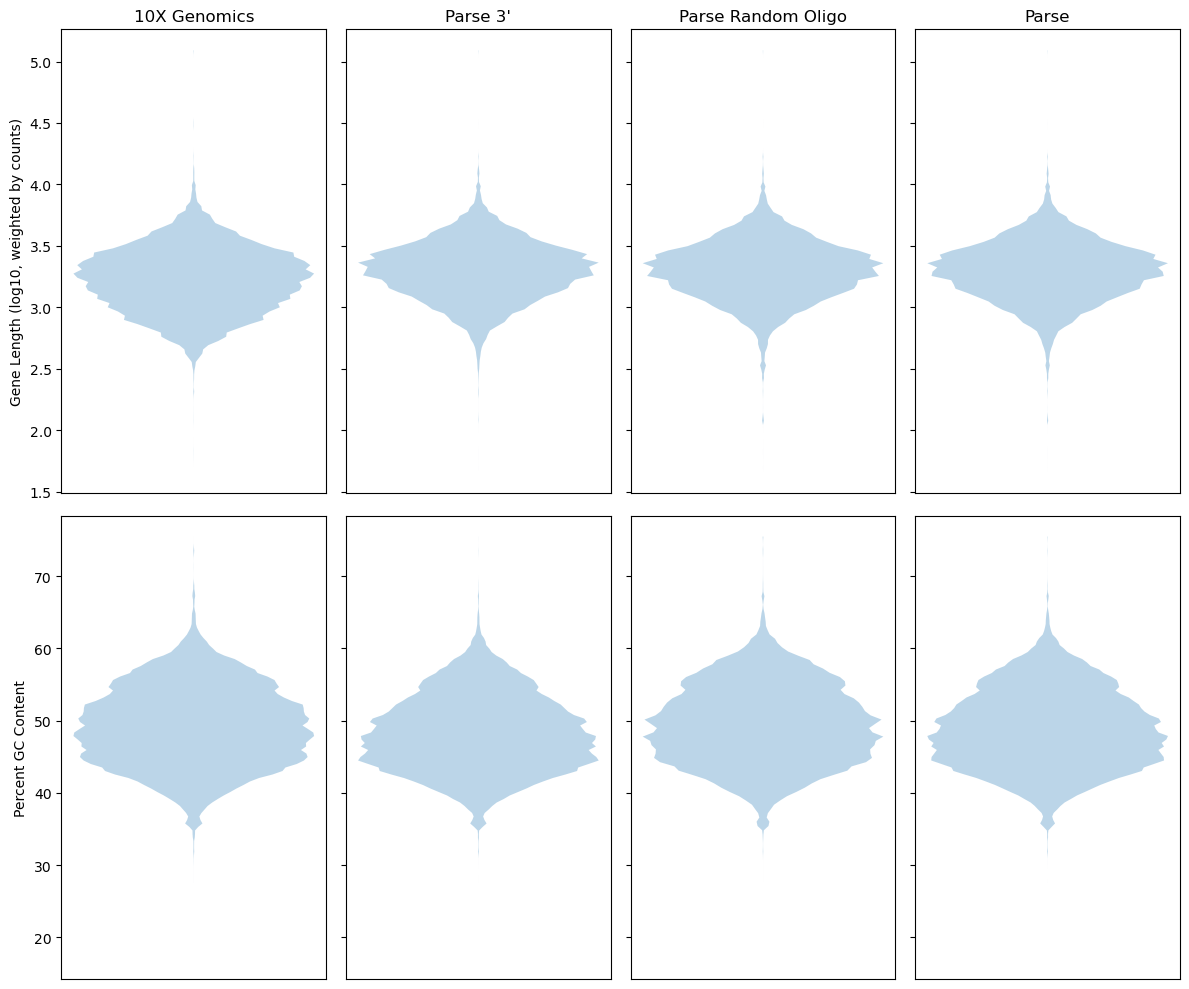

In [12]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)

# Read/Gene Comparisons

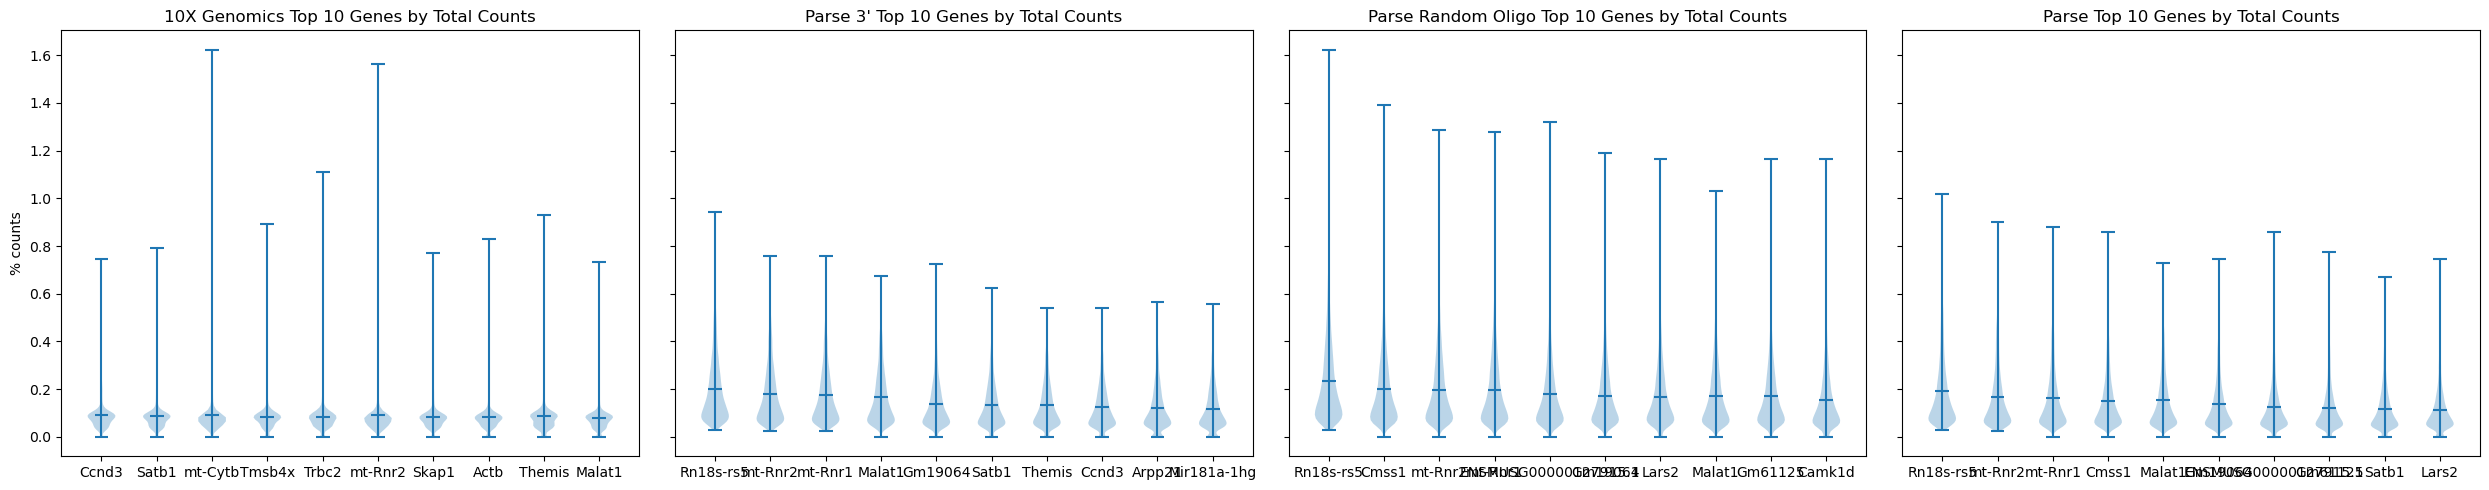

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

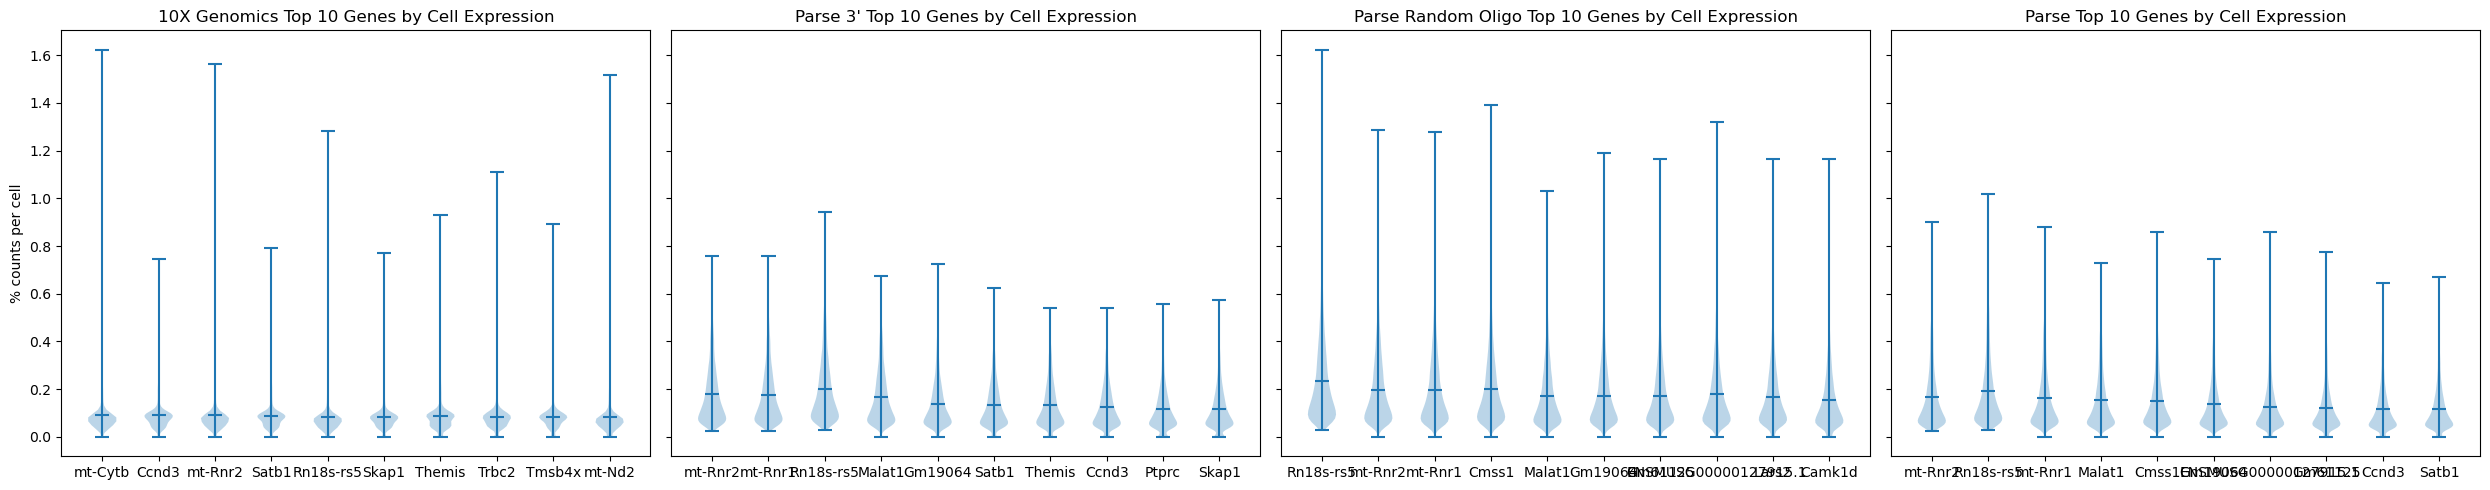

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()

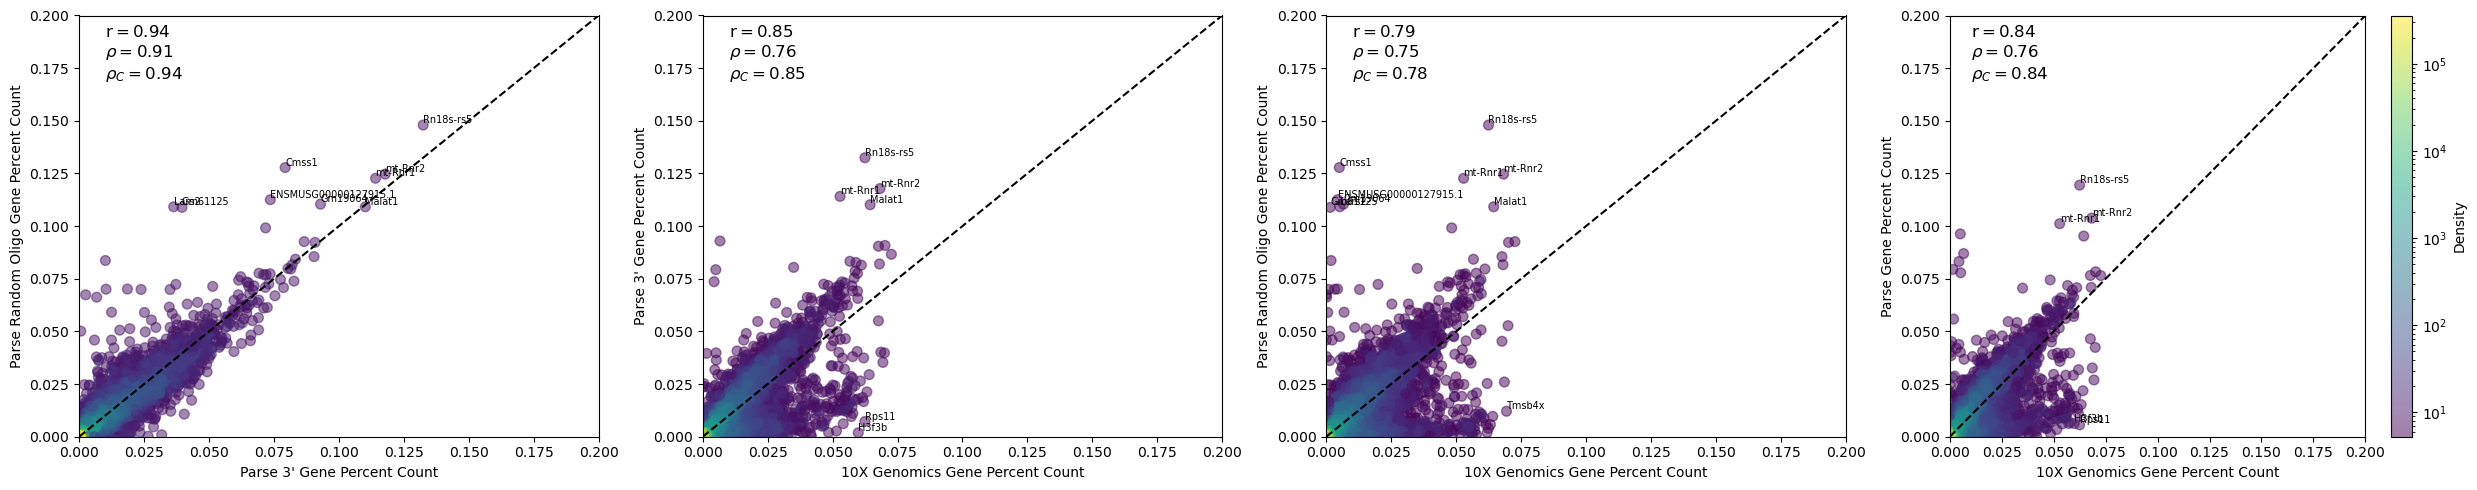

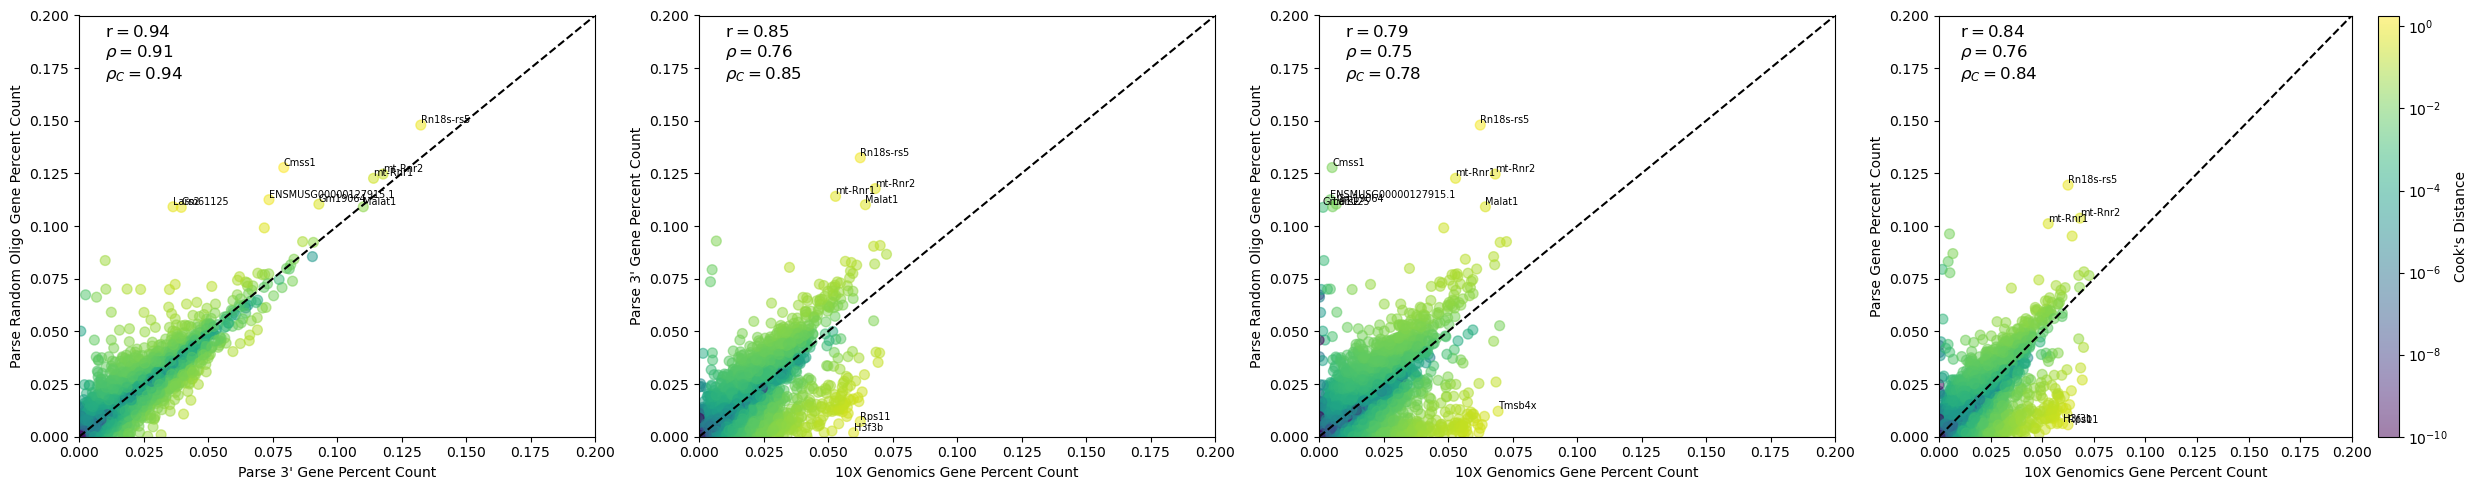

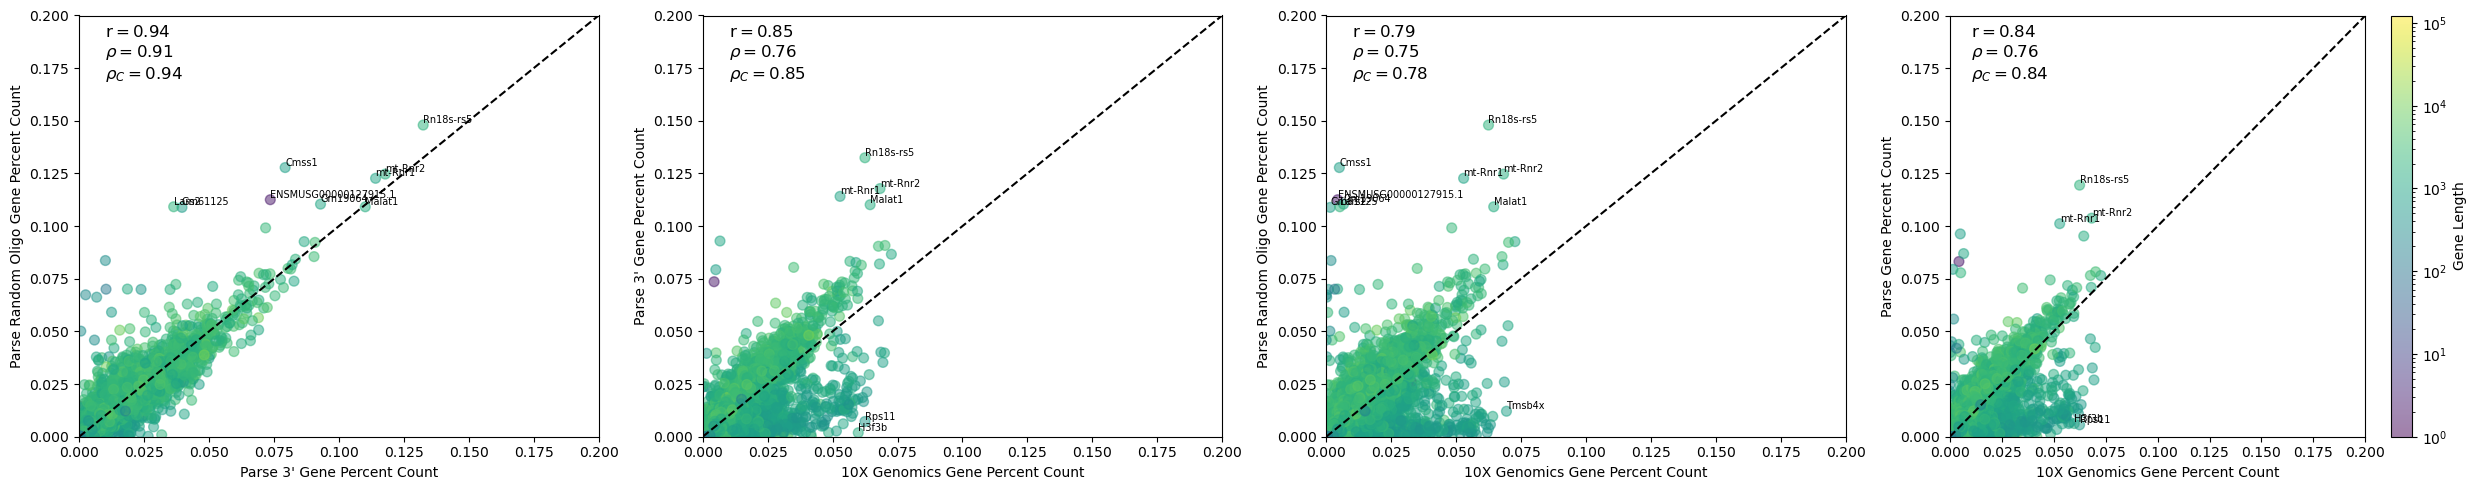

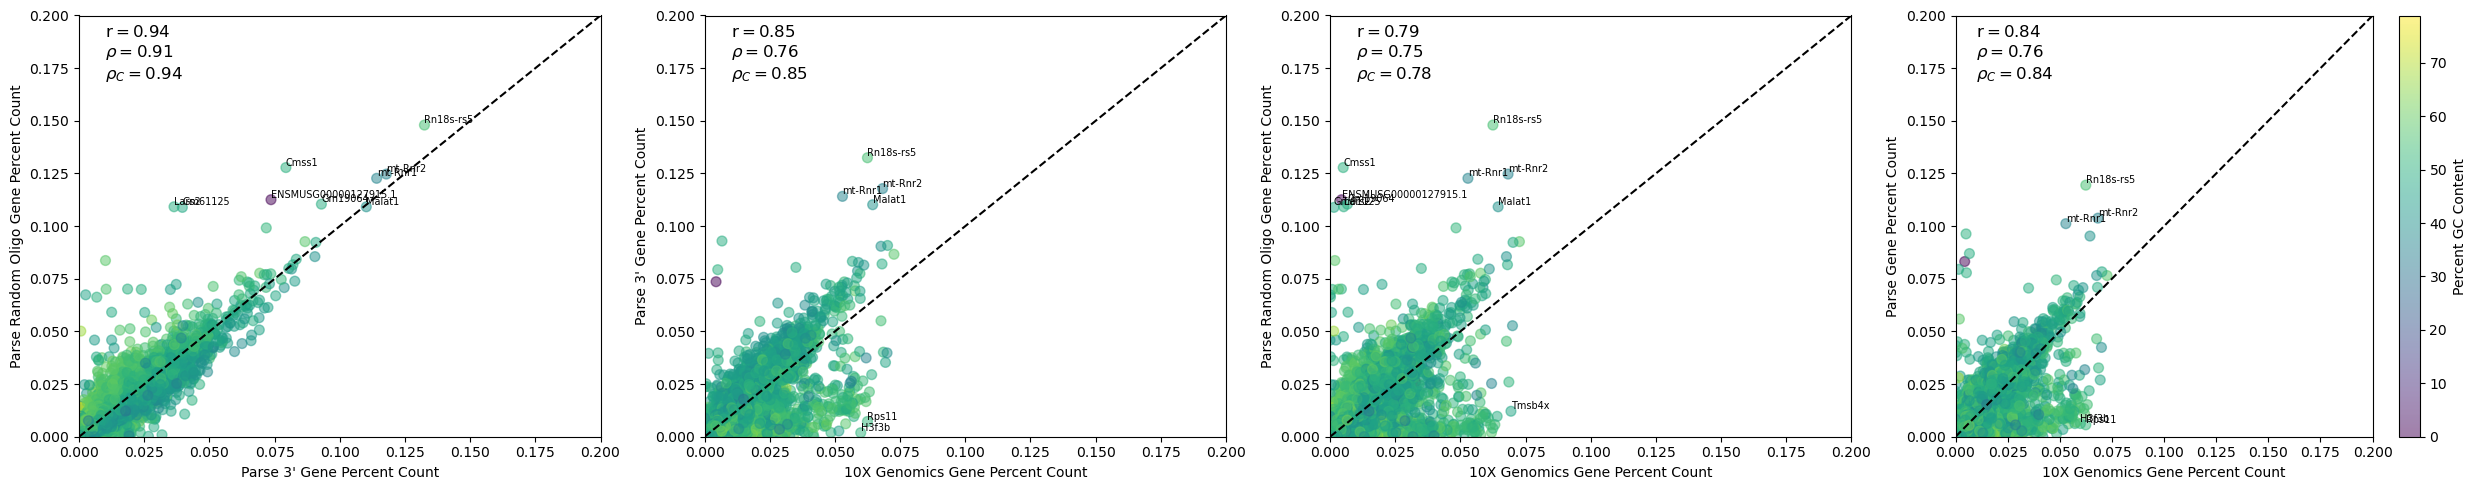

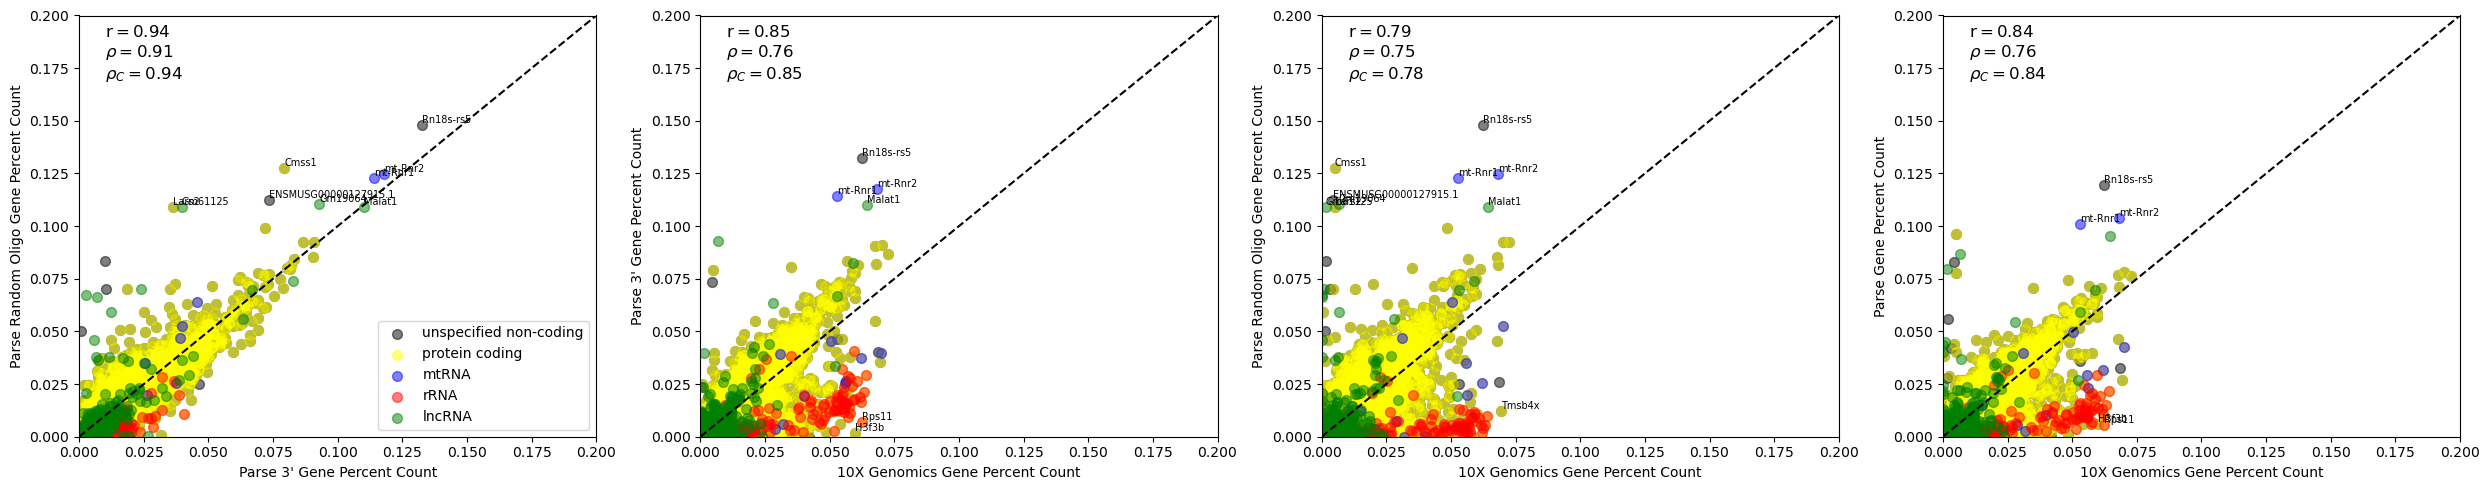

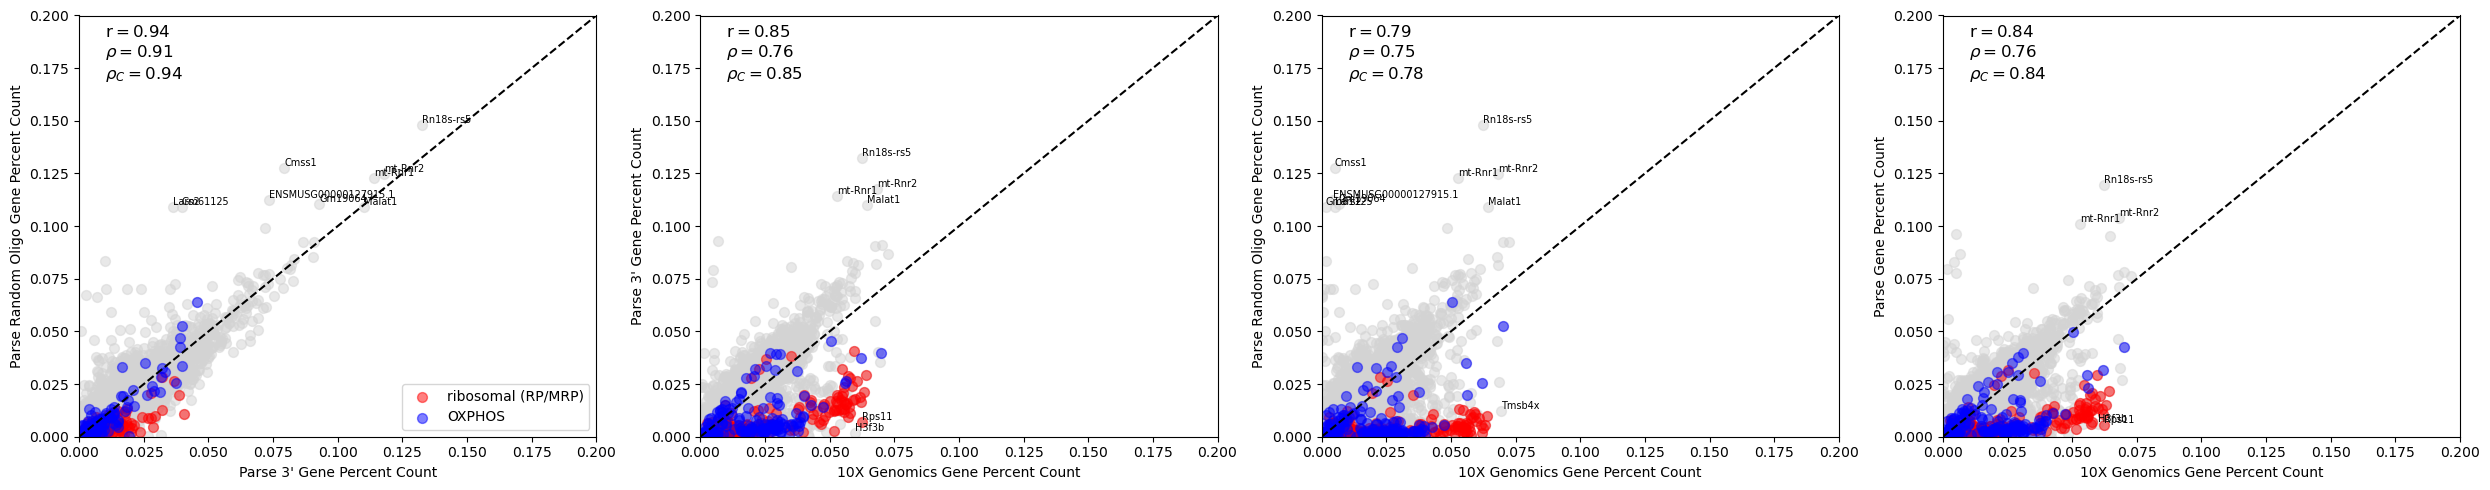

In [15]:
compare_names, compare_dfs = plotting.compare(datasets, 0.2)

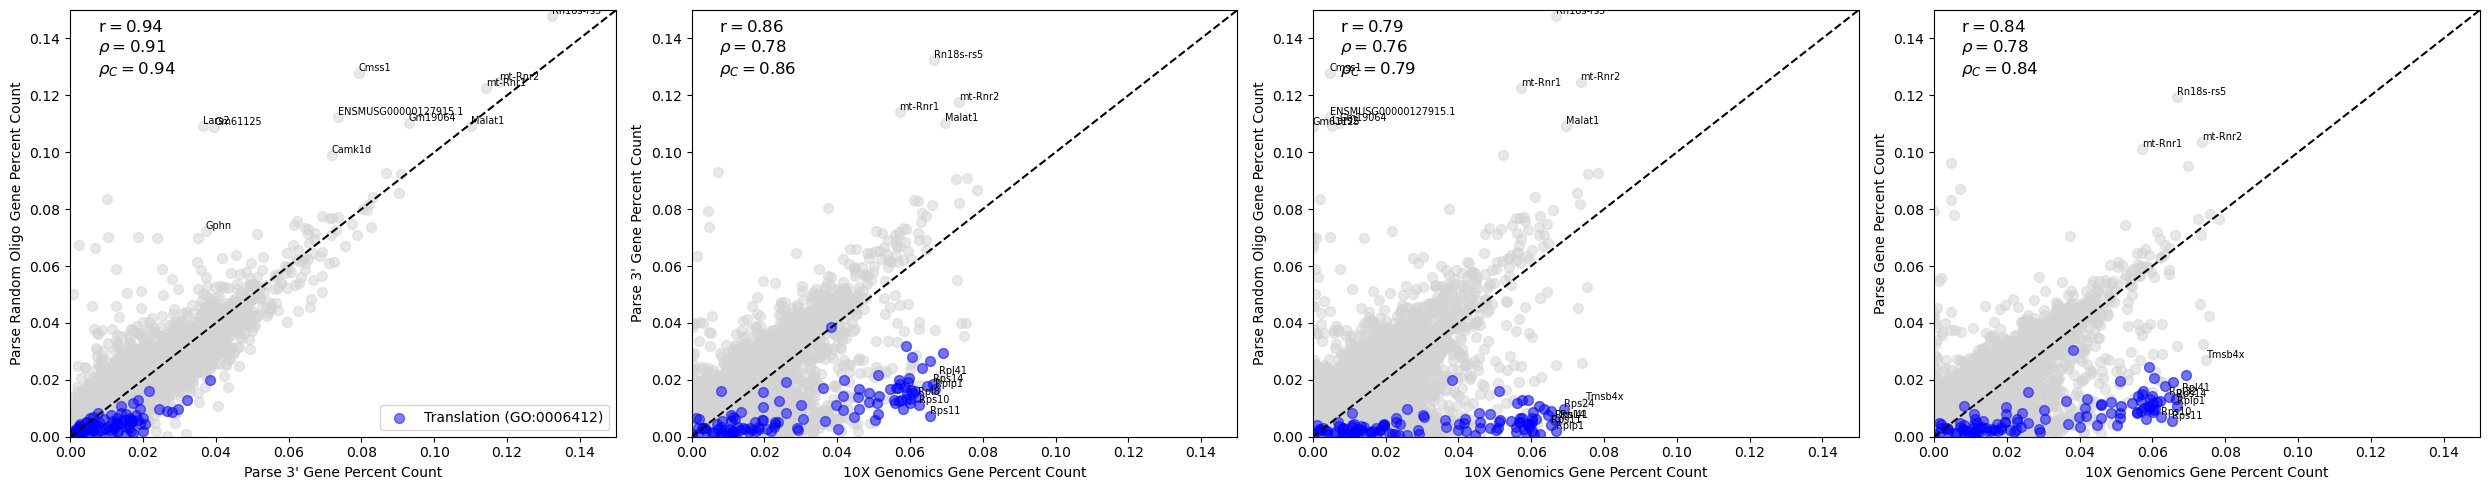

In [16]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Translation (GO:0006412)"]
)

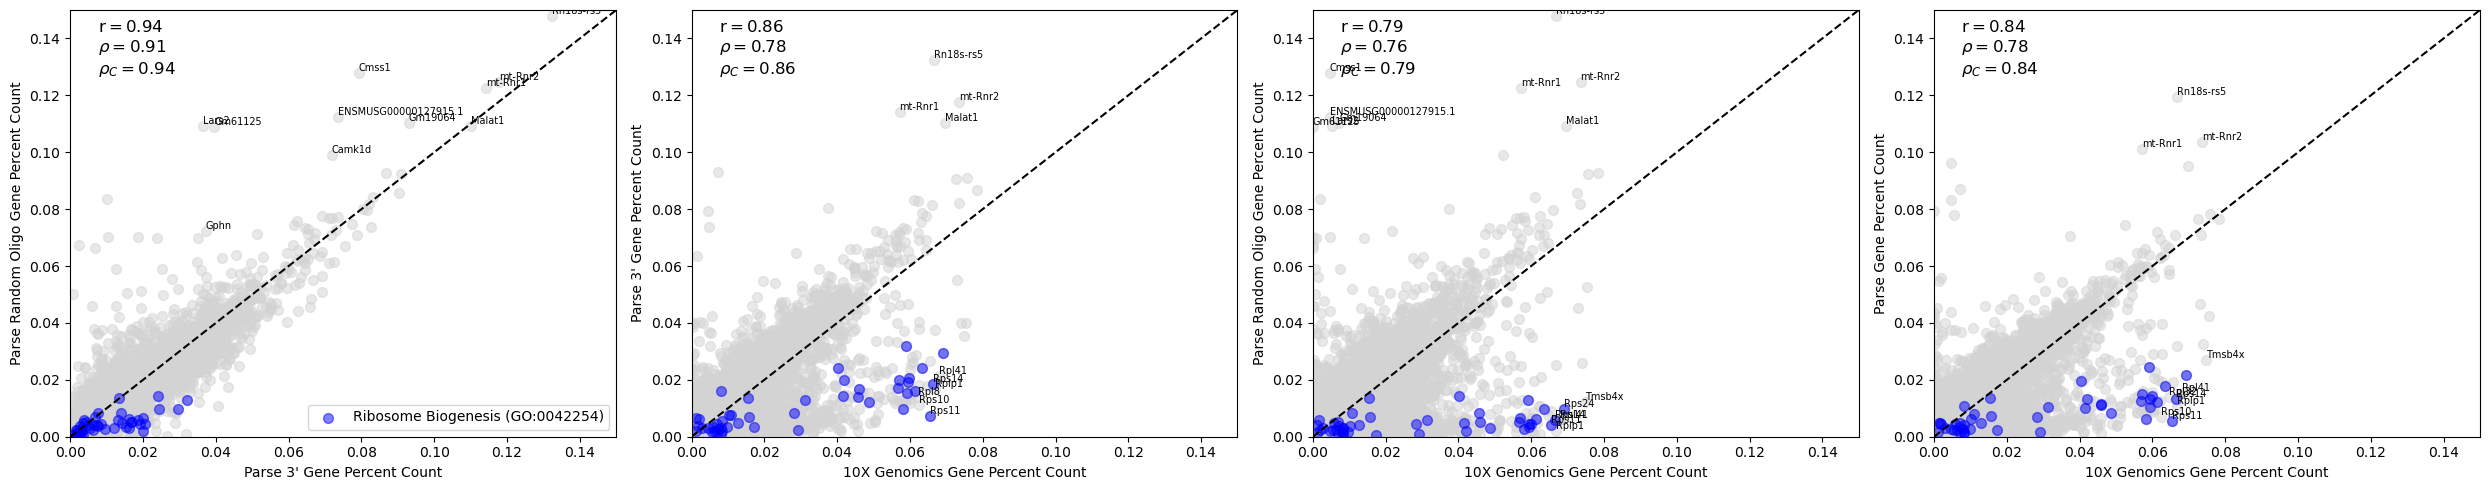

In [17]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Ribosome Biogenesis (GO:0042254)"])

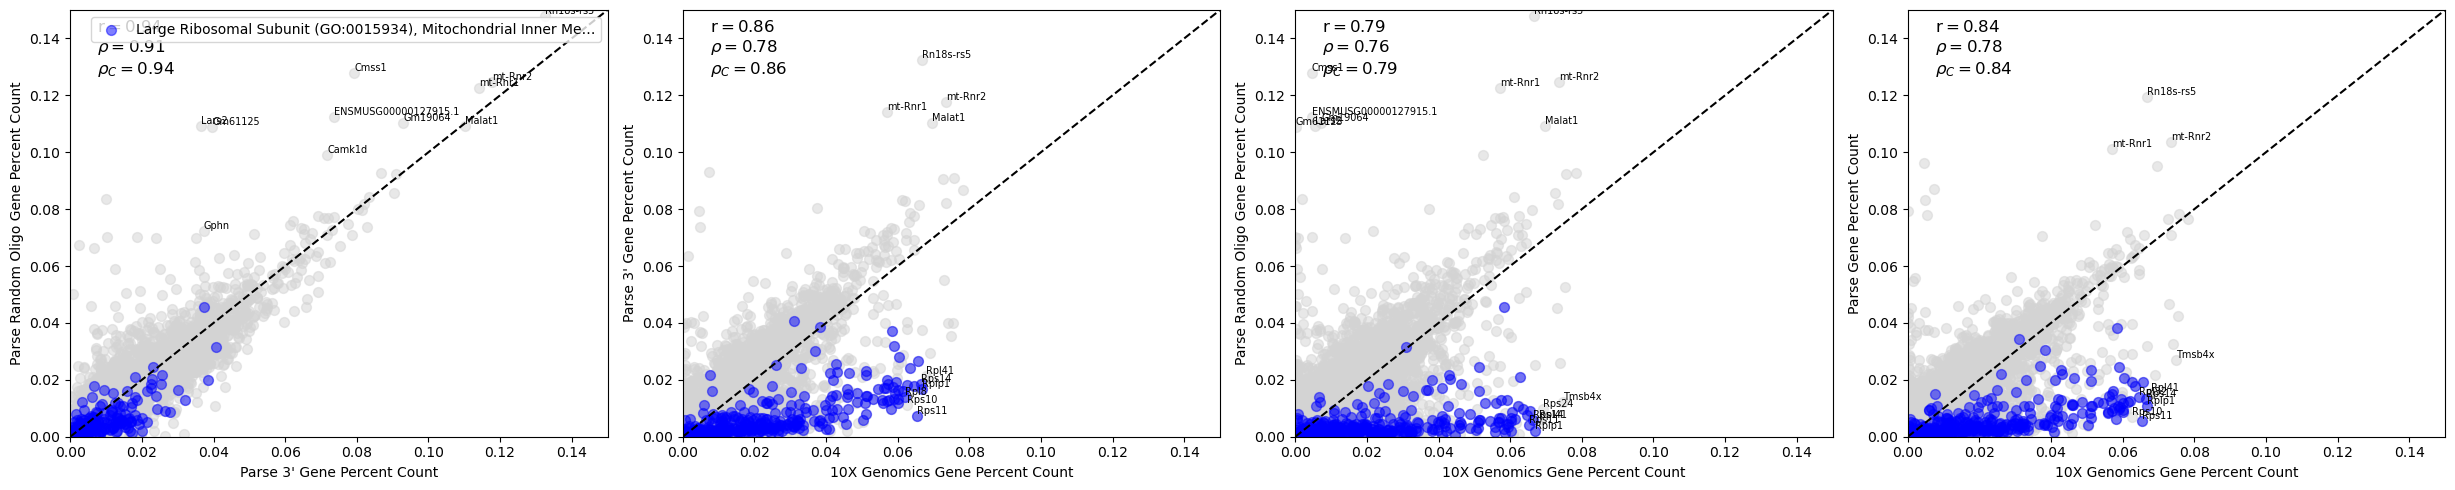

In [18]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Exosome (GO:0070062)", 
           "Large Ribosomal Subunit (GO:0015934)", 
           "Mitochondrial Inner Membrane (GO:0005743)", 
           ])

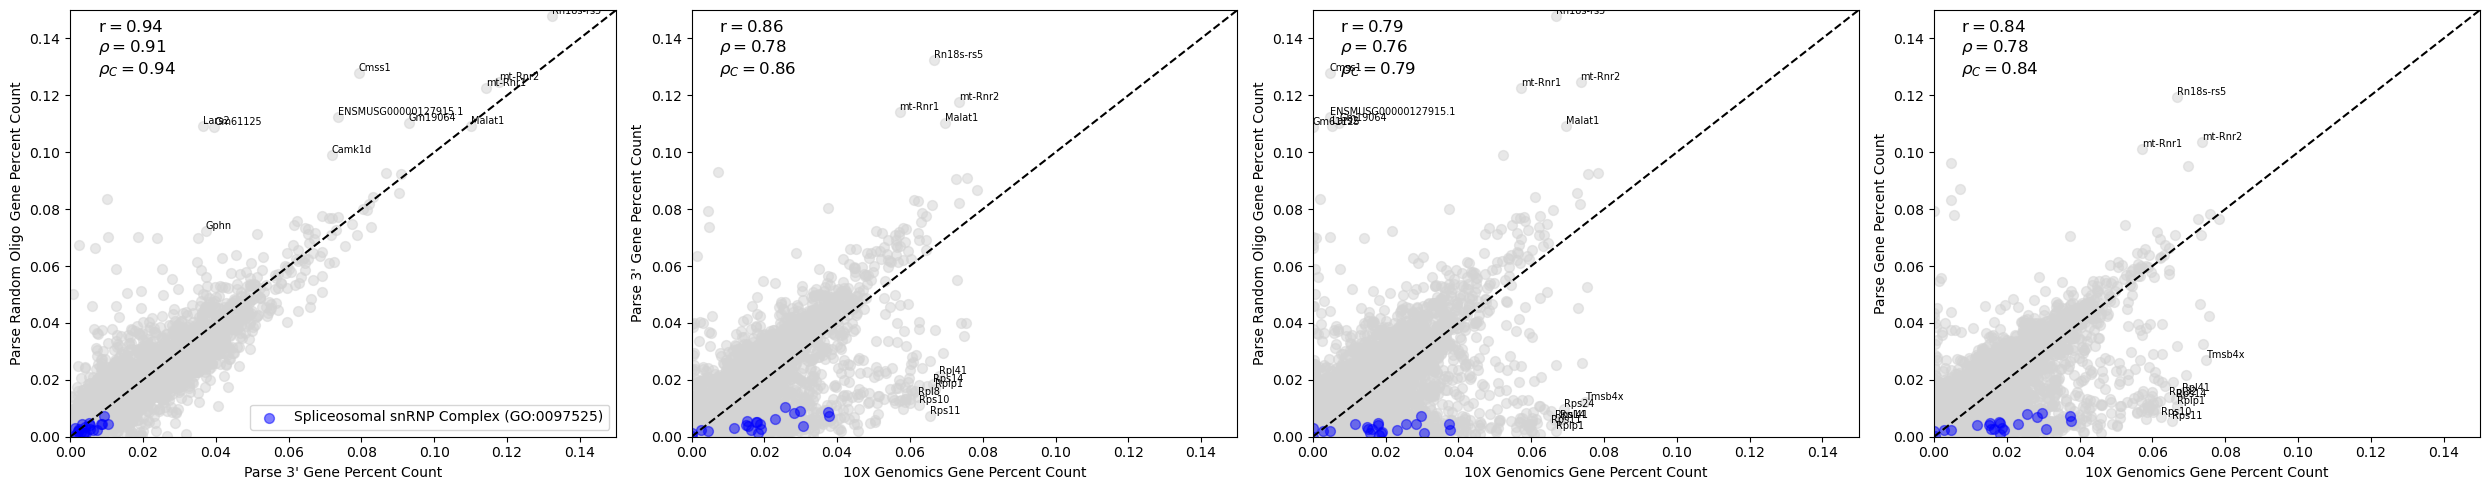

In [19]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Spliceosomal snRNP Complex (GO:0097525)",
           ""
           ])

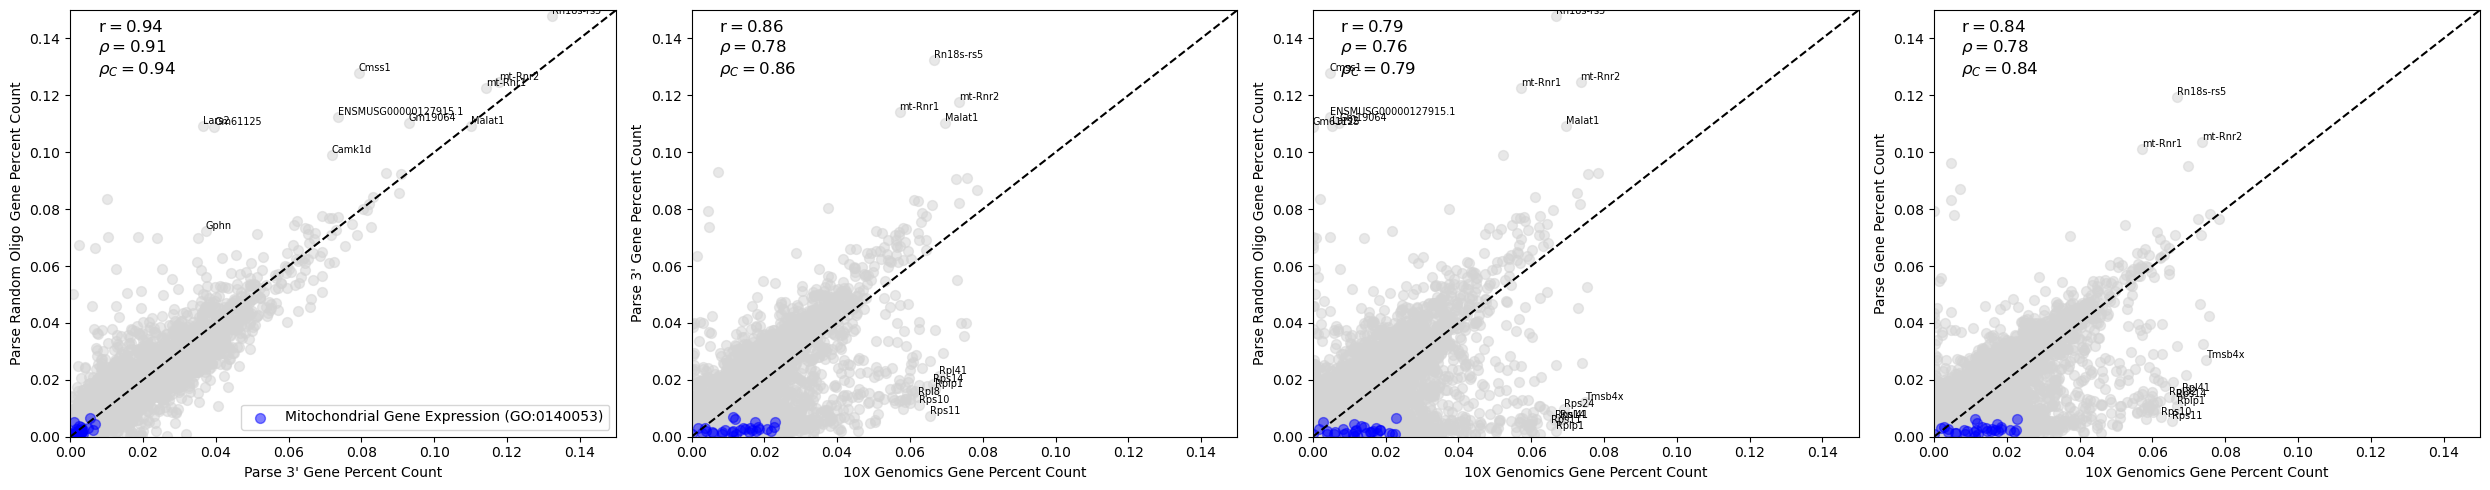

In [20]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Gene Expression (GO:0140053)"])

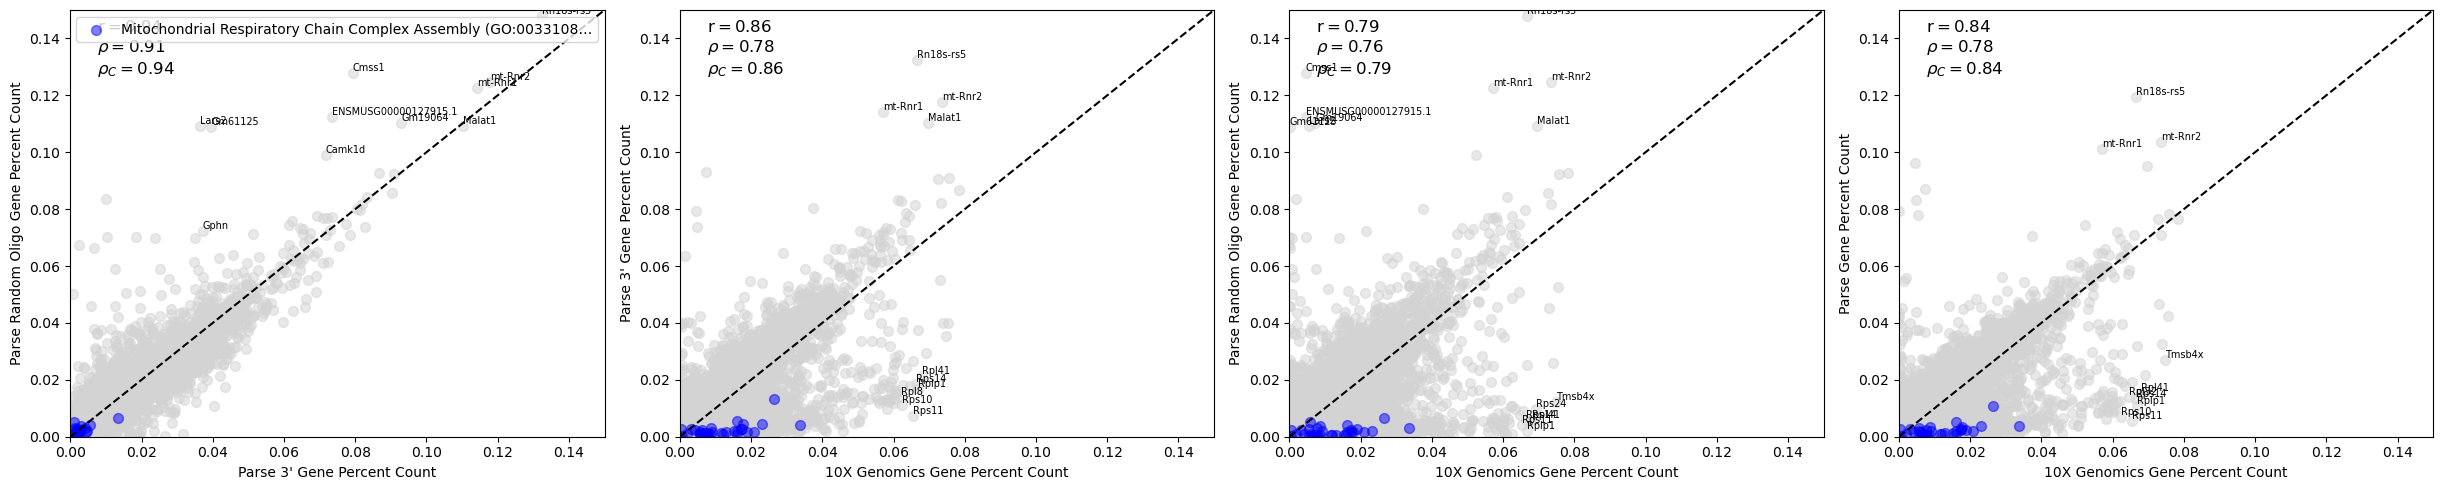

In [21]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:718: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


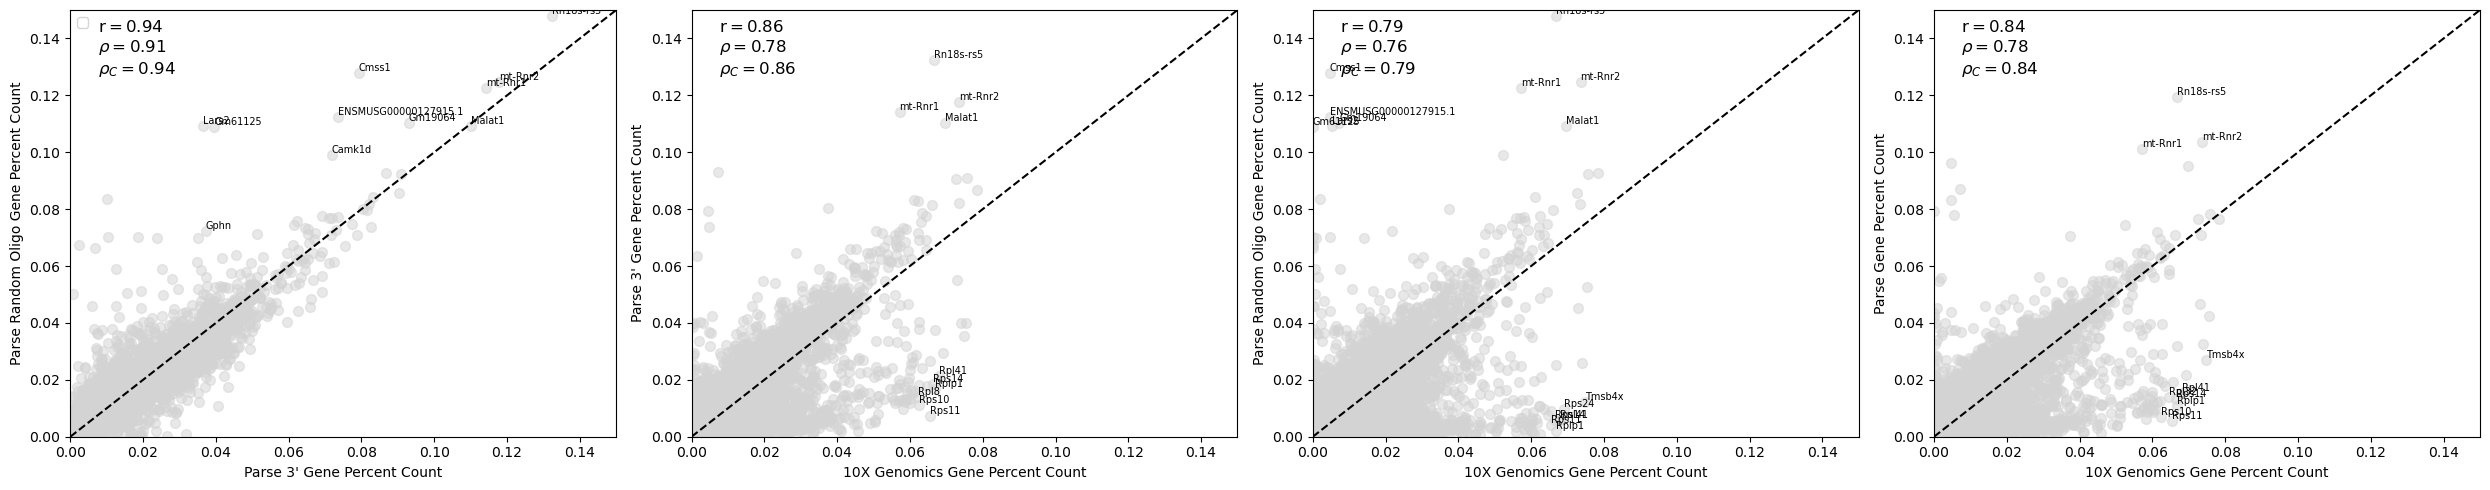

In [22]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Iron-Sulfur Cluster Assembly (GO:0016226)"])

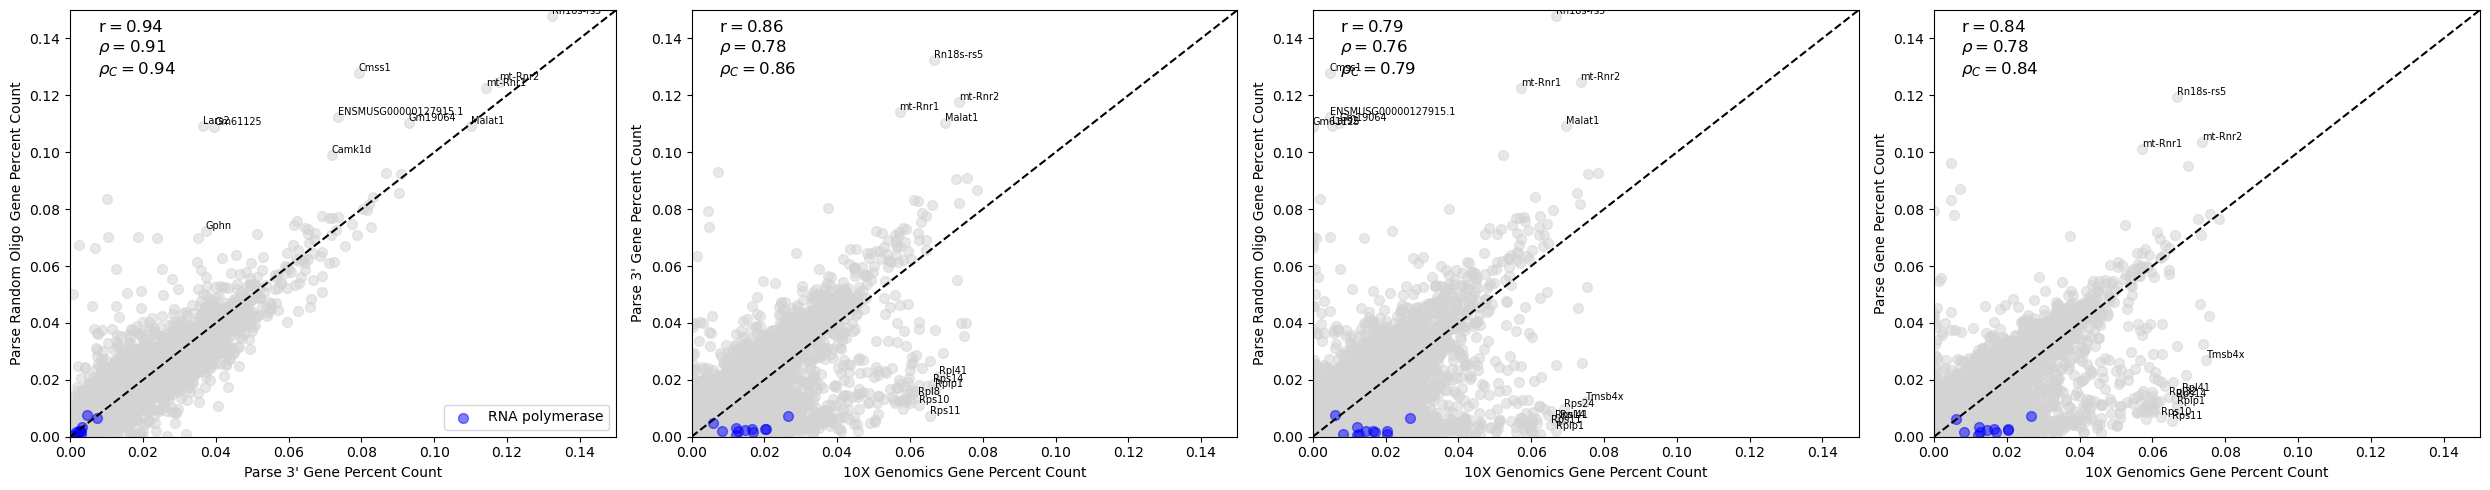

In [23]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["KEGG_2021_Human"],
    terms=["RNA polymerase"])

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:718: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


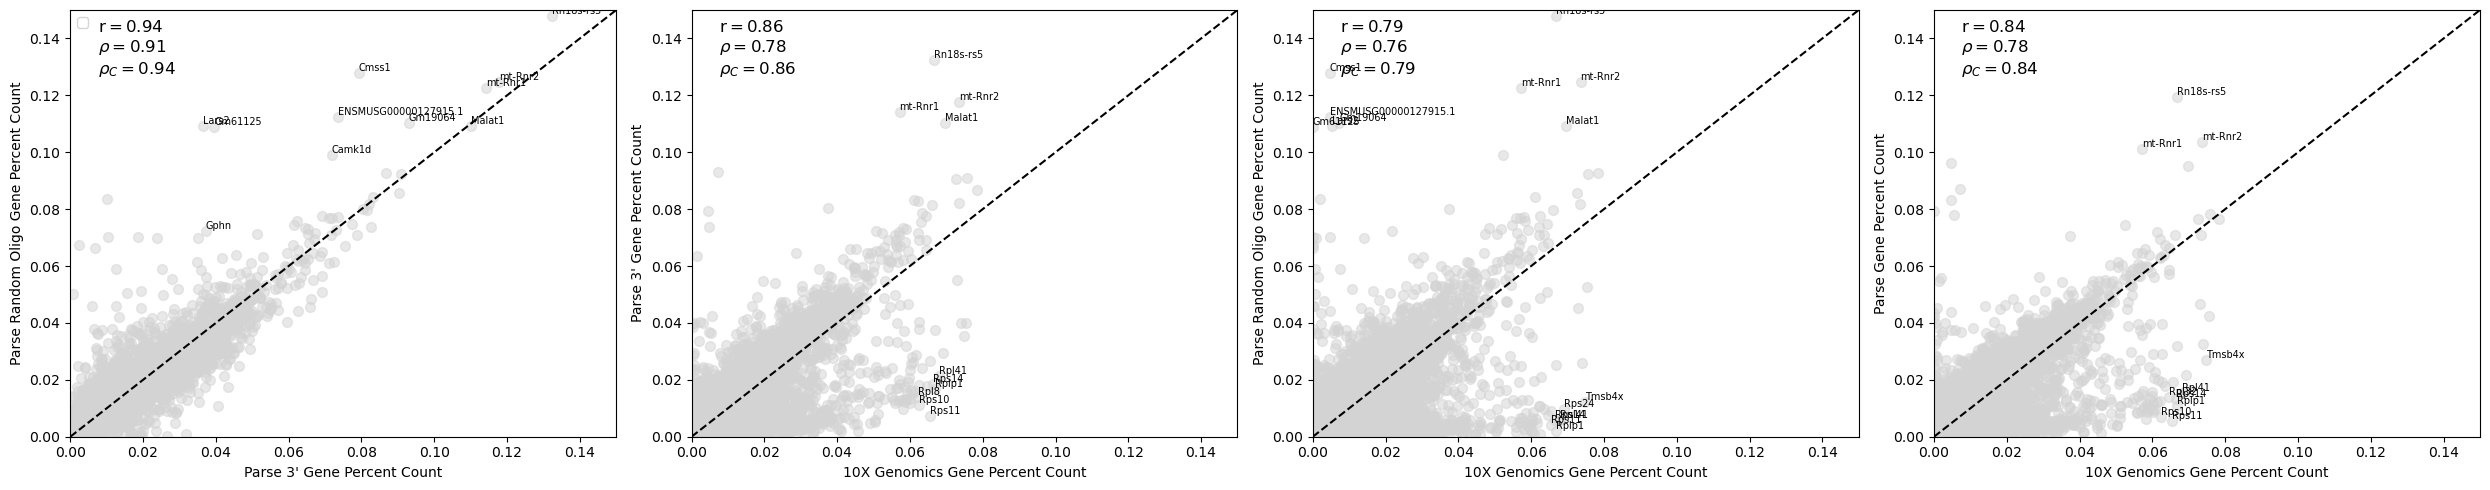

In [24]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["mRNA Splicing, Via Spliceosome (GO:0000398)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:718: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


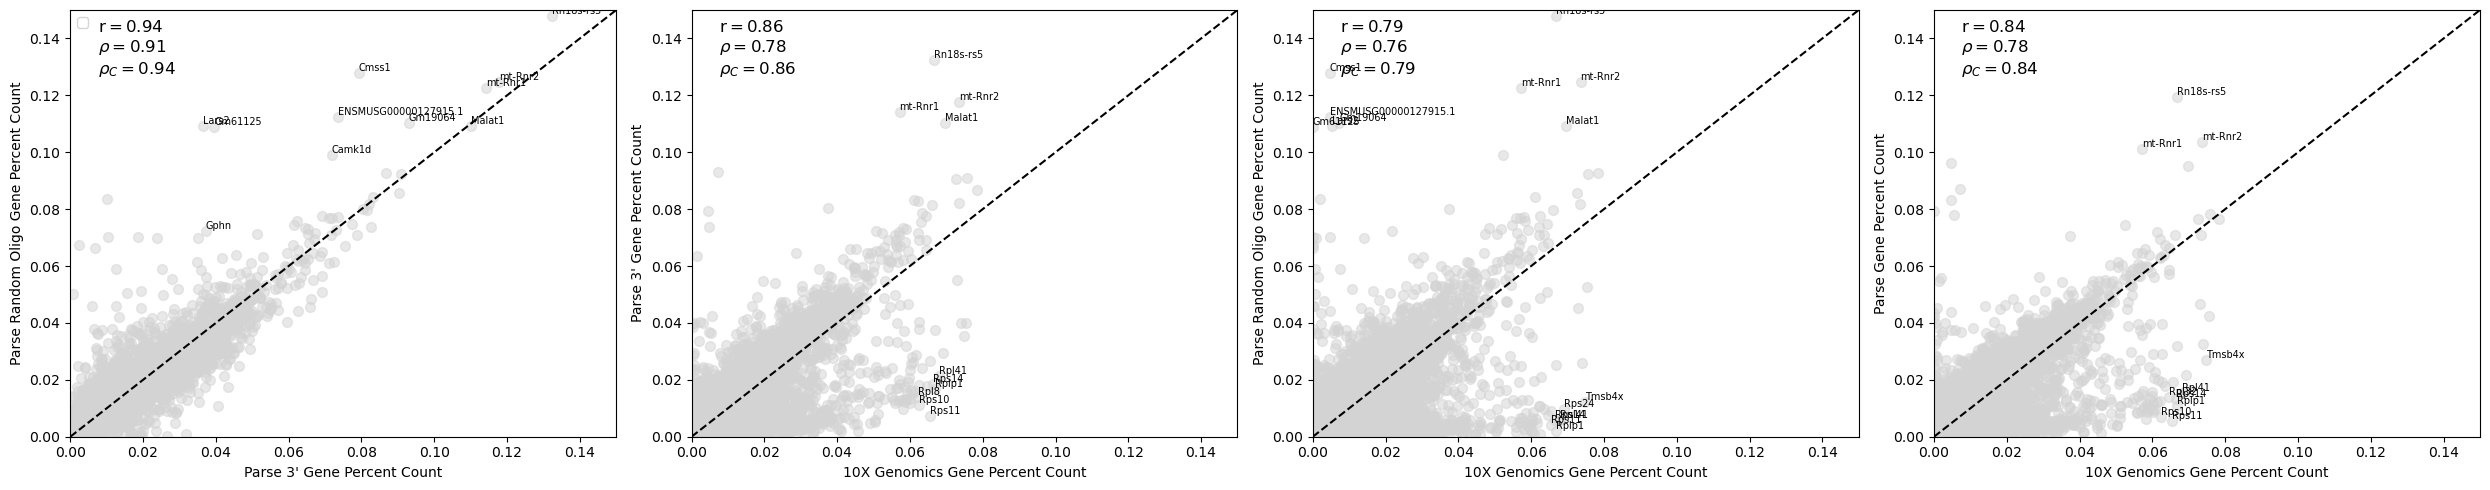

In [25]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Cytoplasmic Translational Initiation (GO:0002183)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:718: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


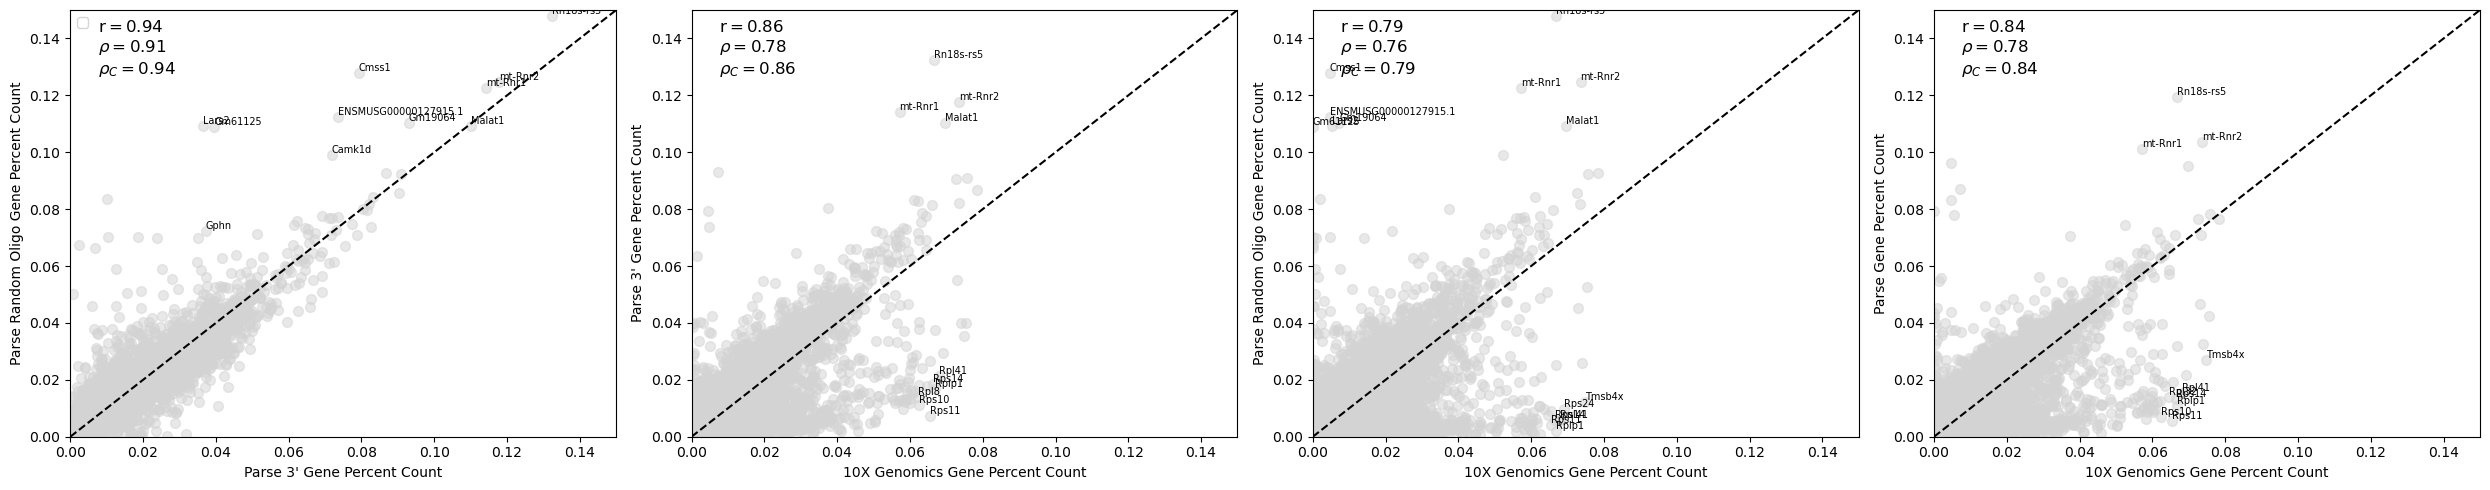

In [26]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Protein Targeting To Mitochondrion (GO:0006626)", "GO BP: Protein Targeting To ER (GO:0045047)"])

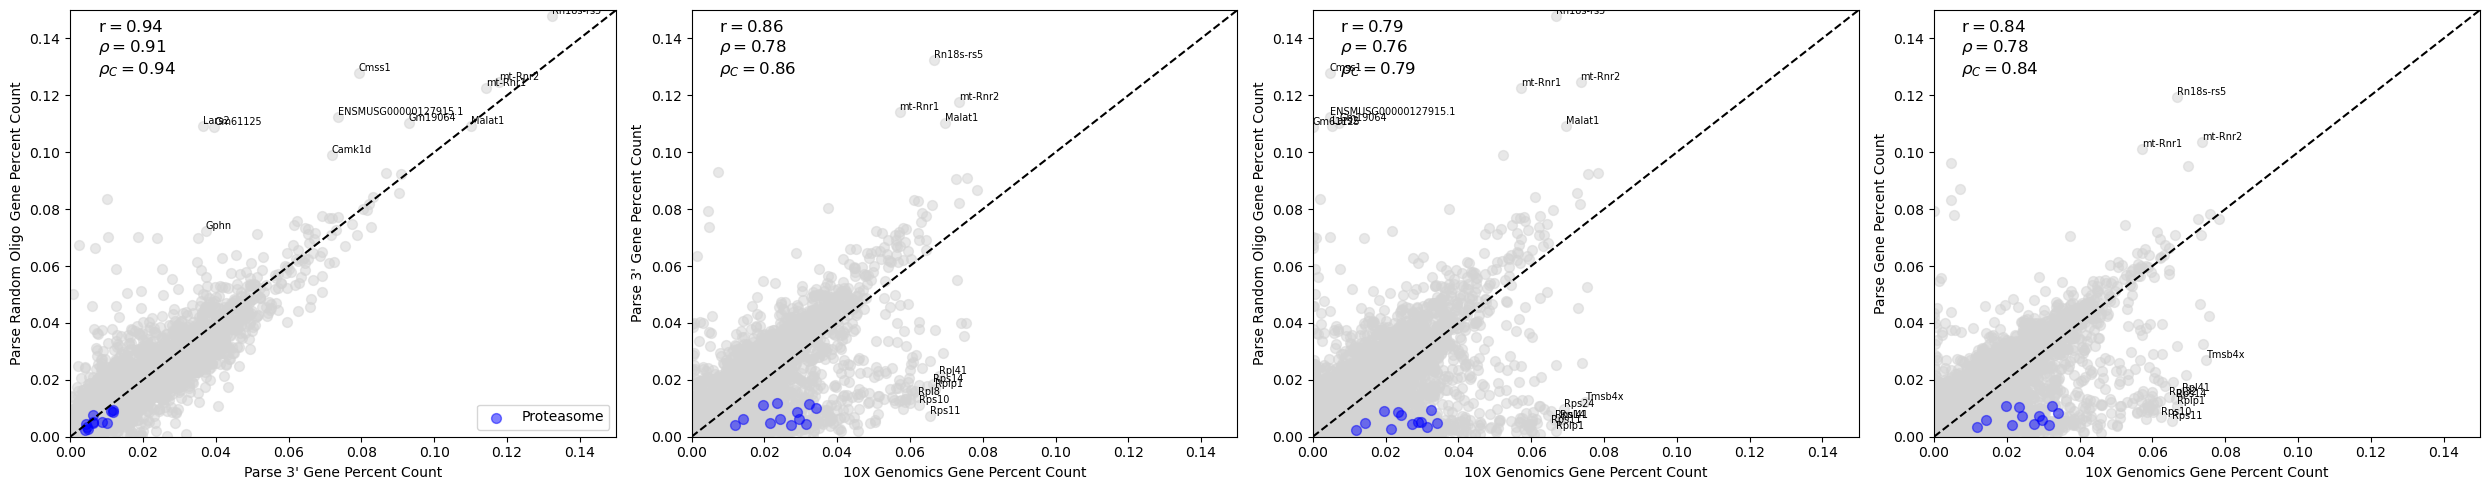

In [27]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["KEGG_2021_Human"],
    terms=["Proteasome"])

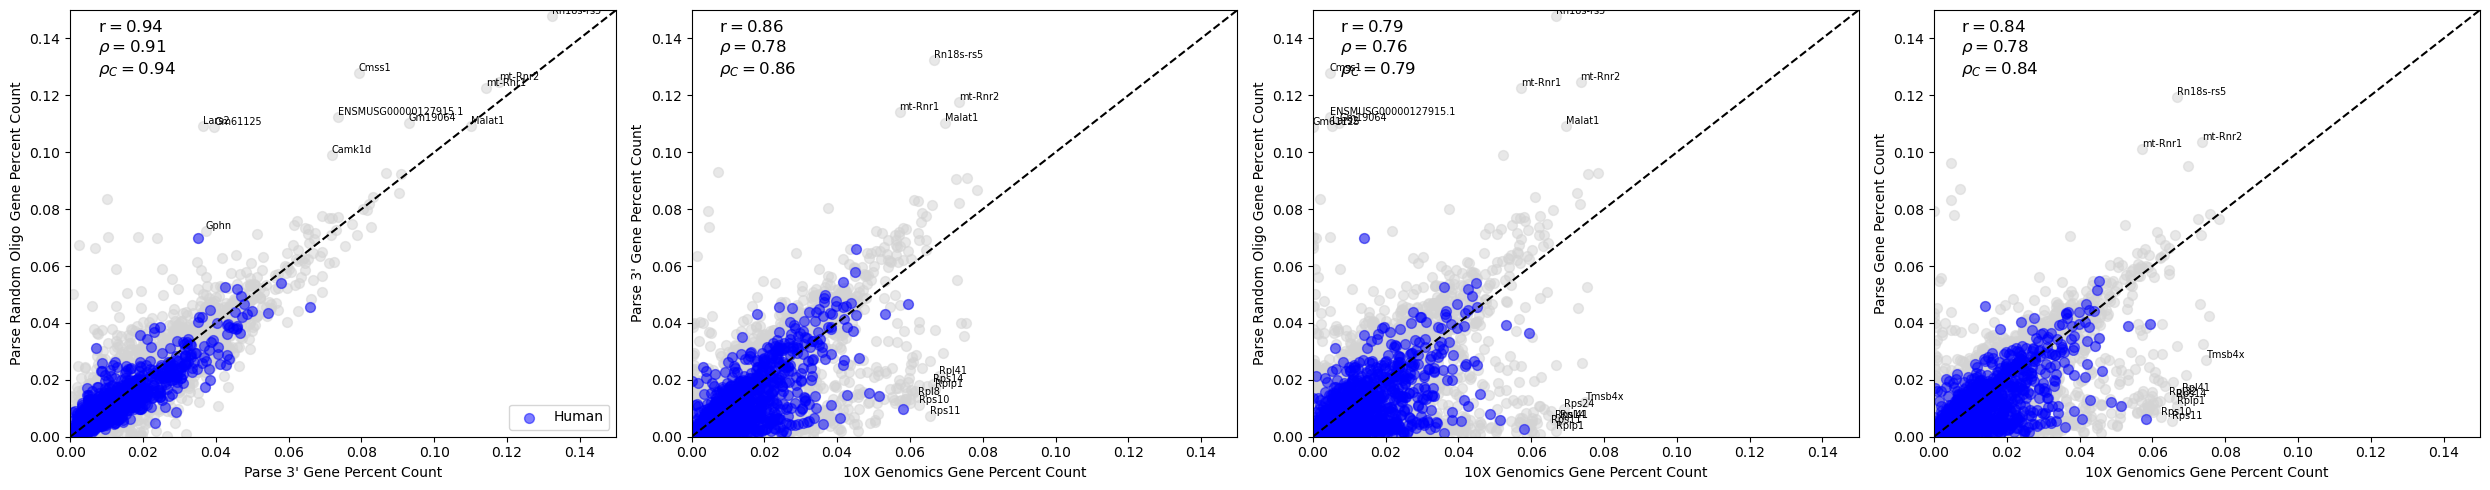

In [28]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/housekeeping_genes.csv",
    gene_sets=["Housekeeping"],
    terms=["Human"])

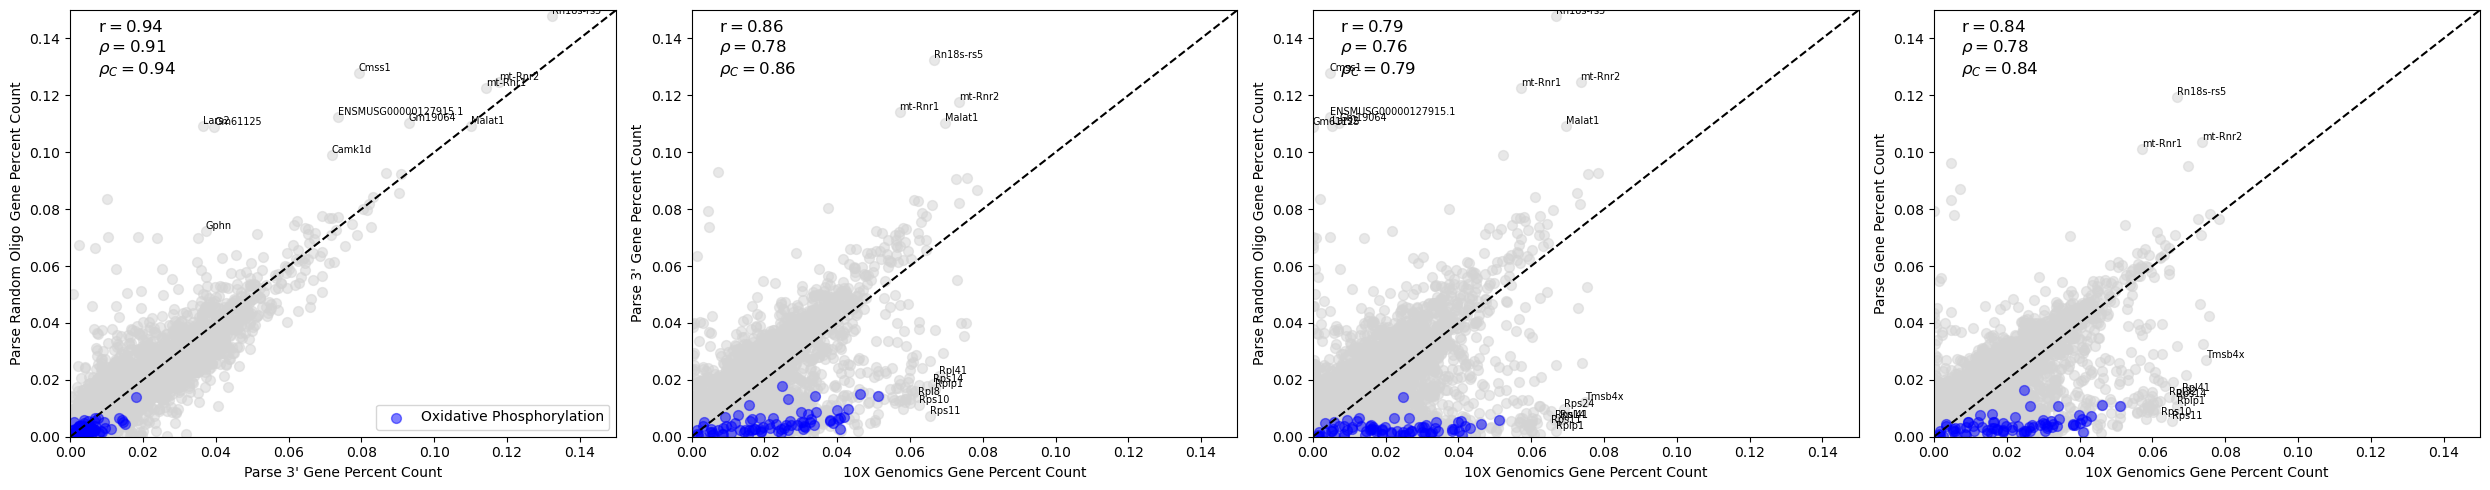

In [29]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["MSigDB_Hallmark_2020"],
    terms=["Oxidative Phosphorylation"]
)

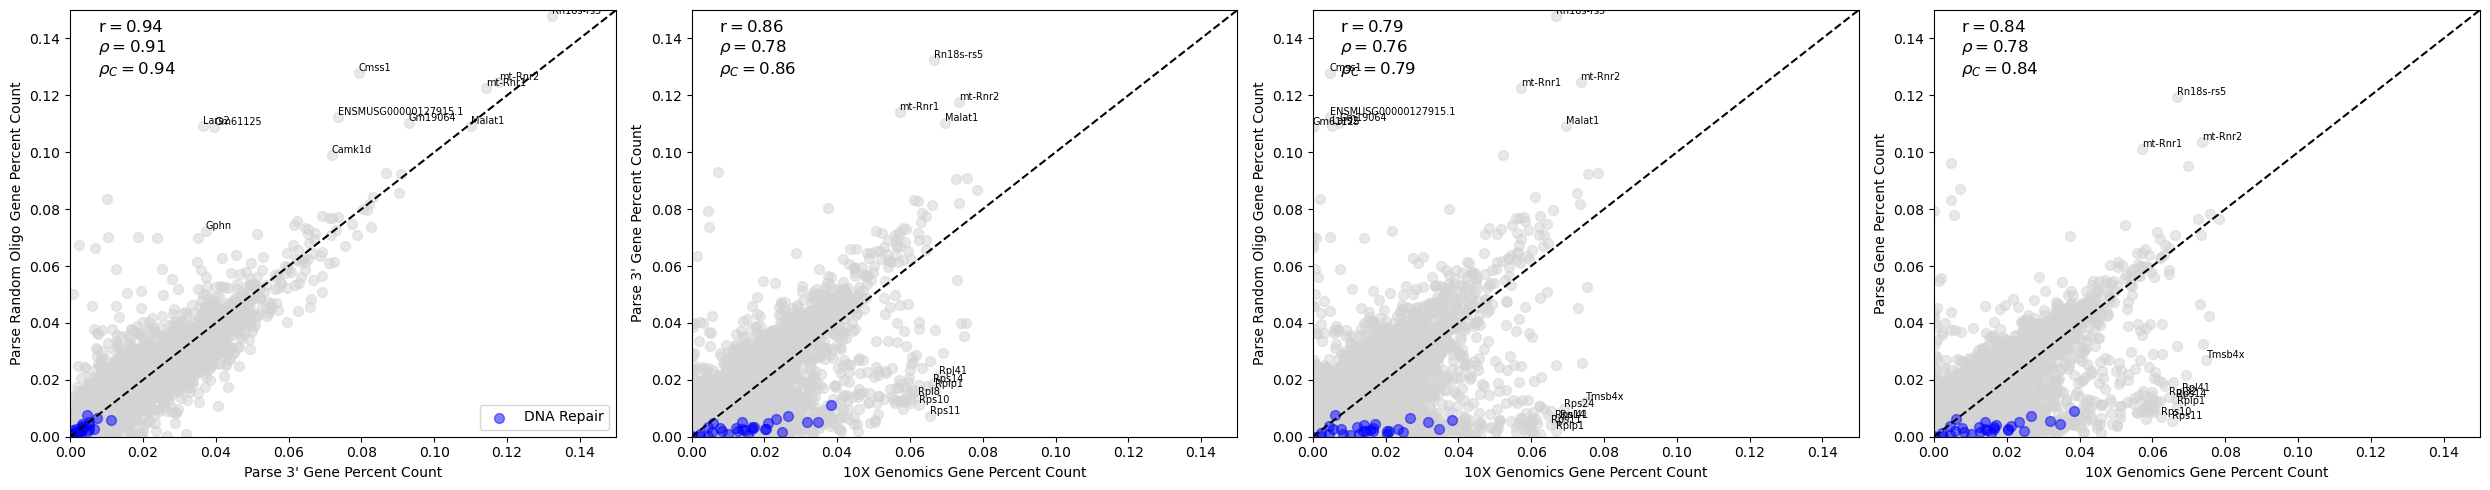

In [30]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=0.15,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["MSigDB_Hallmark_2020"],
    terms=["DNA Repair"]
)